# XTX Paris Take Home Test

### Importation

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import json
import datetime


### Choose interesting Hour:

To select the 1 hour period, we can follow several methods:

    - Method 1: Select a specific Time with an important macro event : CoronaVirus Crisis, Invasion of Ukraine, FED Announcements. Regarding the fact that the market data goes from 2023-04-30 23:00:00 to 2023-05-02 22:59:59.900000, I will not select this solution.

    - Method 2: We can compute volatility to study period where prices fluctuate a lot
    
    - Method 3: We can select our all currencies pair the WMCO time which is 4pm. This is an important hour for market as both US and EU markets are open. And also a lot of derivative contracts use the WMCO as a reference. So the trading volume shloud be higher at this time.

In [2]:
def find_interesting_hour(md):
    """
    Finds the 1-hour window with the highest volatility in mid-price returns.
    
    Parameters:
        md (pd.DataFrame): Market data DataFrame with the following columns:
                           - timestamps (as datetime objects or convertible)
                           - bid and ask princes
                           - mid price
                             
    Returns:
        best_start (pd.Timestamp): Start time of the most volatile 1-hour period.
        best_end   (pd.Timestamp): End time of that period.
        best_vol   (float): Volatility (std. deviation of returns) over that hour.
    """
    # Sort the DataFrame

    md = md.sort_values('ts_ms_datetime').copy()
    

    # Set Timestamps as index for time-based rolling calculations
    md.set_index('ts_ms_datetime', inplace=True)
    
    # Compute percentage returns of the mid-price
    returns = md['mid'].pct_change().dropna()
    
    # Compute rolling volatility over a 1-hour window
    rolling_vol = returns.rolling('1H').std()
    
    # Identify the end of the 1-hour window with the maximum volatility
    best_end = rolling_vol.idxmax()
    best_start = best_end - pd.Timedelta(hours=1)
    best_vol = rolling_vol.loc[best_end]
    
    md.reset_index(inplace=True)
    
    return best_start, best_end, best_vol

### Create a List with all the instruments we study

In [3]:
L_instruments = ["GMMAUSD", "LMDAUSD", "ZTAUSD", "BTAUSD"]

### Load the differents Files

#### Horizon Ticks

In [4]:
with open("horizon_ticks", "r") as f:
    horizon_ticks = json.load(f) #List

In [5]:
len(horizon_ticks)

1370

In [6]:
horizon_ticks[:5] # Visualize the first 5 elements

[-10000, -9900, -9800, -9700, -9600]

# Study the data for One Currency 

In [7]:
instrument = 'LMDAUSD'

with open(f"{instrument}.json", "r") as f:
        meta = json.load(f)
meta

{'rhs_ccy': 'USD', 'lhs_ccy': 'LMDA', 'tick_size': 1e-05}

In [8]:
with open(f"{instrument}.json", "r") as f:
        meta = json.load(f)
    
    # Load market data; assumed columns include: 'timestamp', 'bid', 'ask'
md = pd.read_csv(f"{instrument}_md.csv")

    

In [9]:
md.shape

(1728000, 3)

In [10]:
md.columns

Index(['ts_ms', 'bid', 'ask'], dtype='object')

In [11]:
md.head()

,ts_ms,bid,ask
0,1.682896e+12,0.799900,0.800100
1,1.682896e+12,0.799805,0.800185
2,1.682896e+12,0.799805,0.800185
3,1.682896e+12,0.799805,0.800185
4,1.682896e+12,0.799815,0.800195


We can see that ts_ms is not in datetime and that Mid price is missing

In [12]:
trades = pd.read_csv(f"{instrument}_trades.csv")
trades.shape

(3157, 7)

In [13]:
trades.head()

,ts_ms,trade_id,side,size,px,lhs_ccy,rhs_ccy
0,1.682913e+12,340,S,10000.0,0.805250,LMDA,USD
1,1.683050e+12,2848,B,6000.0,0.796900,LMDA,USD
2,1.683067e+12,3142,S,6000.0,0.801790,LMDA,USD
3,1.682909e+12,267,B,4000.0,0.802085,LMDA,USD
4,1.682955e+12,1105,S,7000.0,0.797810,LMDA,USD


We can see that ts_ms is not in datetime

# Expand To All The Currencies

### Functions to Use

In [14]:
def load_md(instrument):
    """
    import md for an instrument and convert ts_ms (int to datetime) and create mid
    
    Parameters:
        instrument : str
                           
                             
    Returns:
         md (pd.DataFrame): Market data DataFrame with the following columns:
                           - ts_ms (int objects)
                           - bid and ask prices (float)
                           - mid prices (float)
                           - ts_ms_datetime (ts_ms as datetime object)
    """
    try:
        md = pd.read_csv(f"{instrument}_md.csv")
         # Convert 'ts_ms' to datetime
        md['ts_ms_datetime'] = pd.to_datetime(md['ts_ms'], unit='ms')
        # Compute mid-price
        md['mid'] = (md['bid'] + md['ask']) / 2
        return md
    except:
        print (f"The file {instrument}_md.csv doesn't exist")
        

def load_trades(instrument):
    """
    import trades for an instrument and convert ts_ms (int to datetime) and create mid
    
    Parameters:
        instrument : str
                           
                             
    Returns:
         trades (pd.DataFrame): Market data DataFrame with the following columns:
                           - ts_ms (int)
                           - trade_id (int)
                           - side (str)
                           - size (float)
                           - px (float)
                           - lhs_ccy (str)
                           - rhs_ccy(str)
                           - ts_ms_datetime (ts_ms as datetime object)
    """
    try:
        trades = pd.read_csv(f"{instrument}_trades.csv")
         # Convert 'ts_ms' to datetime
        trades['ts_ms_datetime'] = pd.to_datetime(trades['ts_ms'], unit='ms')
        
        return trades
    except:
        print (f"The file {instrument}_trades.csv doesn't exist")

In [15]:
def filter_for_plot(df):
    df_subset = df[(df['ts_ms_datetime'] >= best_start) & (df['ts_ms_datetime'] <= best_end)]
    return df_subset

First Trade date for GMMAUSD is: 2023-05-01 13:35:09.824999936
Last Trade date for GMMAUSD is: 2023-05-02 16:07:01.475000064
First Price date for GMMAUSD is: 2023-04-30 23:00:00
Last Price date for GMMAUSD is: 2023-05-02 22:59:59.900000
For GMMAUSD the selected interesting hour is from 2023-04-30 22:00:00.200000 to 2023-04-30 23:00:00.200000 (volatility: 0.000059)

First Trade date for LMDAUSD is: 2023-05-01 03:57:09.249999872
Last Trade date for LMDAUSD is: 2023-05-02 12:16:29.849999872
First Price date for LMDAUSD is: 2023-04-30 23:00:00
Last Price date for LMDAUSD is: 2023-05-02 22:59:59.900000
For LMDAUSD the selected interesting hour is from 2023-05-02 02:53:10 to 2023-05-02 03:53:10 (volatility: 0.000013)

First Trade date for ZTAUSD is: 2023-05-02 21:12:46.950000128
Last Trade date for ZTAUSD is: 2023-05-02 01:03:32.550000128
First Price date for ZTAUSD is: 2023-04-30 23:00:00
Last Price date for ZTAUSD is: 2023-05-02 22:59:59.900000
For ZTAUSD the selected interesting hour is f

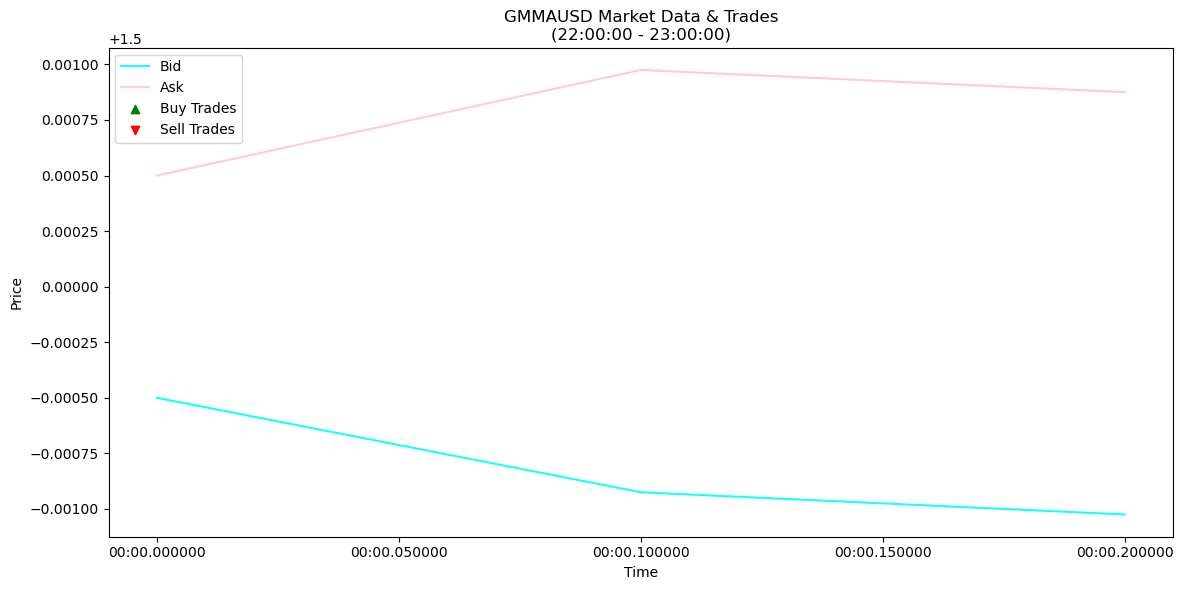

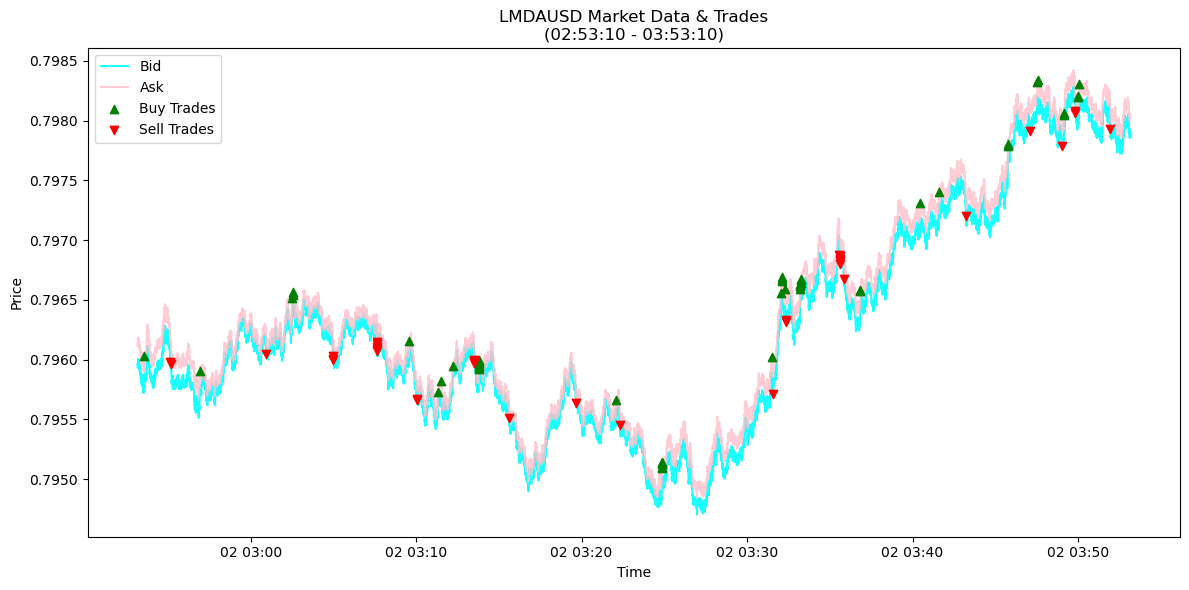

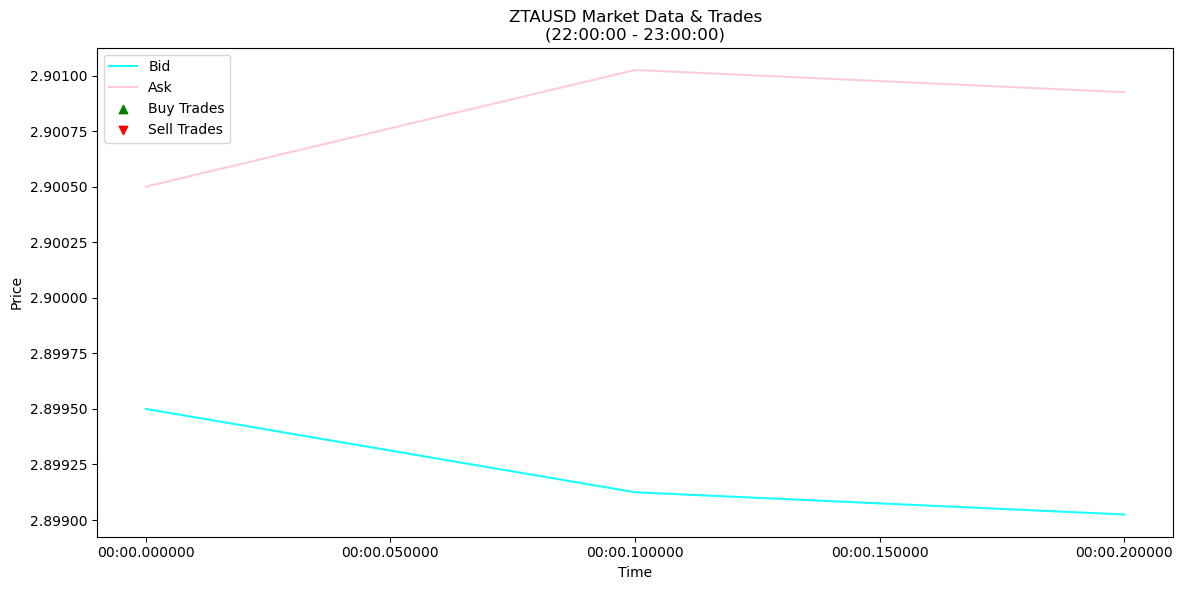

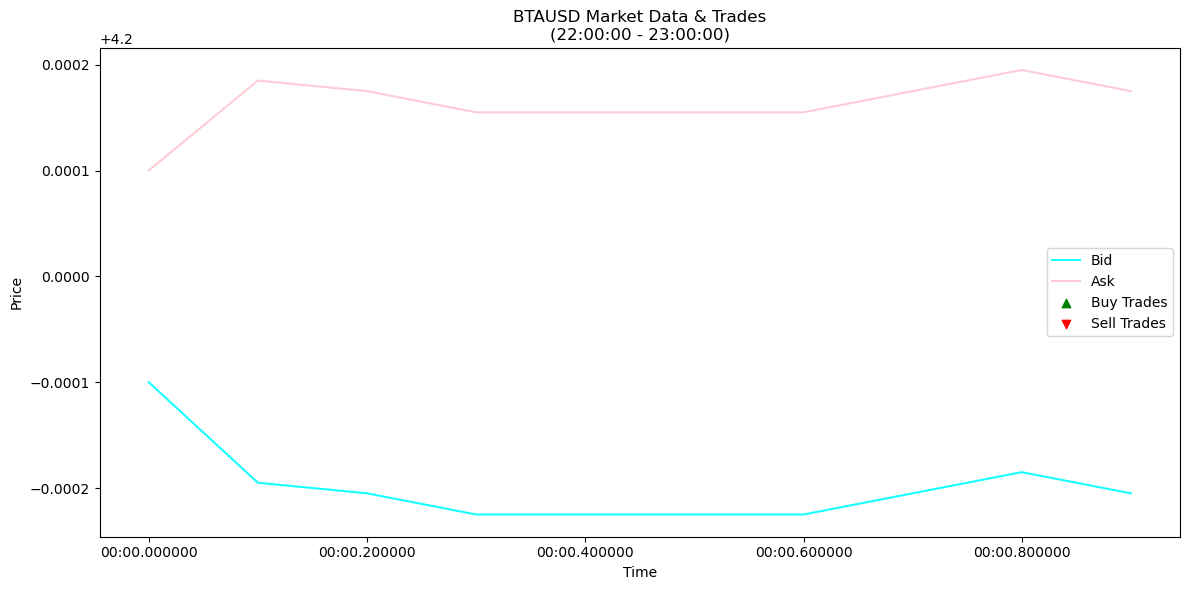

In [16]:
for instrument in L_instruments:
    # Load Data
    # Load metadata
    with open(f"{instrument}.json", "r") as f:
        meta = json.load(f)
    
    #Load market Data
    md = load_md(instrument)

    
    # Load trades data
    trades = load_trades(instrument)

    
    print('First Trade date for ' + instrument +' is: '+ str(trades['ts_ms_datetime'].iloc[0]))
    print('Last Trade date for ' + instrument +' is: '+ str(trades['ts_ms_datetime'].iloc[-1]))
    print('First Price date for ' + instrument +' is: '+ str(md['ts_ms_datetime'].iloc[0]))
    print('Last Price date for ' + instrument +' is: '+ str(md['ts_ms_datetime'].iloc[-1]))
    
    # Step 2: Choose An Interesting 1 Hour (Using Method 2 and the function developed)
    best_start, best_end, best_vol = find_interesting_hour(md)
    print(f"For {instrument} the selected interesting hour is from {best_start} to {best_end} (volatility: {best_vol:.6f})" + '\n')
    
    md_subset = filter_for_plot(md)
    trades_subset = filter_for_plot(trades)

    # Plot market data & trades during the interesting hour

    plt.figure(figsize=(12, 6))
    plt.plot(md_subset['ts_ms_datetime'], md_subset['bid'], label='Bid', color='cyan', alpha=0.9)
    plt.plot(md_subset['ts_ms_datetime'], md_subset['ask'], label='Ask', color='pink', alpha=0.8)
    
    # Separate trades by side
    buy_trades = trades_subset[trades_subset['side']== 'B']
    sell_trades = trades_subset[trades_subset['side'] == 'S']
    
    # Plot buy trades with green upward triangles
    plt.scatter(buy_trades['ts_ms_datetime'], buy_trades['px'], 
                marker='^', color='green', label='Buy Trades', zorder=5)
    
    # Plot sell trades with red downward triangles
    plt.scatter(sell_trades['ts_ms_datetime'], sell_trades['px'], 
                marker='v', color='red', label='Sell Trades', zorder=5)
    
    plt.xlabel("Time")
    plt.ylabel("Price")
    plt.title(f"{instrument} Market Data & Trades\n({best_start.strftime('%H:%M:%S')} - {best_end.strftime('%H:%M:%S')})")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{instrument}_market_trades_vol.png")
    

It seems that method 2 works well for LMDAUSD but not for other currency so lets try method 3

# A plot visualizing both the market data and the trades, for an interesting 1 hour period of your choice.

First Trade date for GMMAUSD is: 2023-05-01 13:35:09.824999936
Last Trade date for GMMAUSD is: 2023-05-02 16:07:01.475000064
First Price date for GMMAUSD is: 2023-04-30 23:00:00
Last Price date for GMMAUSD is: 2023-05-02 22:59:59.900000
Selected fixed hour: 2023-05-01 16:00:00 to 2023-05-01 17:00:00

First Trade date for LMDAUSD is: 2023-05-01 03:57:09.249999872
Last Trade date for LMDAUSD is: 2023-05-02 12:16:29.849999872
First Price date for LMDAUSD is: 2023-04-30 23:00:00
Last Price date for LMDAUSD is: 2023-05-02 22:59:59.900000
Selected fixed hour: 2023-05-01 16:00:00 to 2023-05-01 17:00:00

First Trade date for ZTAUSD is: 2023-05-02 21:12:46.950000128
Last Trade date for ZTAUSD is: 2023-05-02 01:03:32.550000128
First Price date for ZTAUSD is: 2023-04-30 23:00:00
Last Price date for ZTAUSD is: 2023-05-02 22:59:59.900000
Selected fixed hour: 2023-05-01 16:00:00 to 2023-05-01 17:00:00

First Trade date for BTAUSD is: 2023-05-02 20:02:20.424999936
Last Trade date for BTAUSD is: 2023-

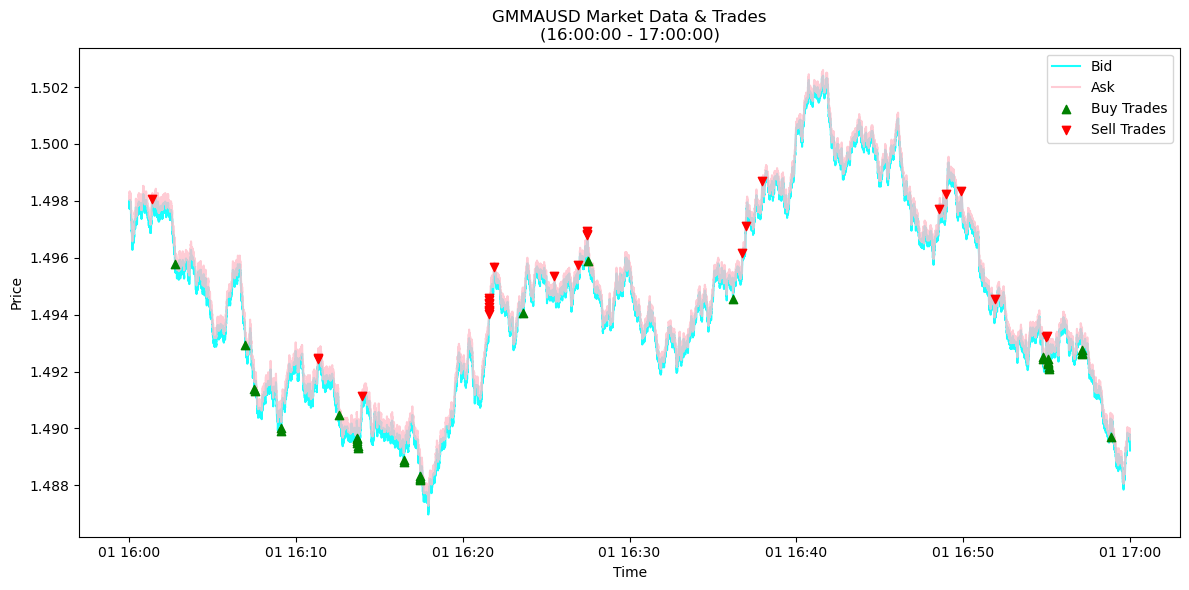

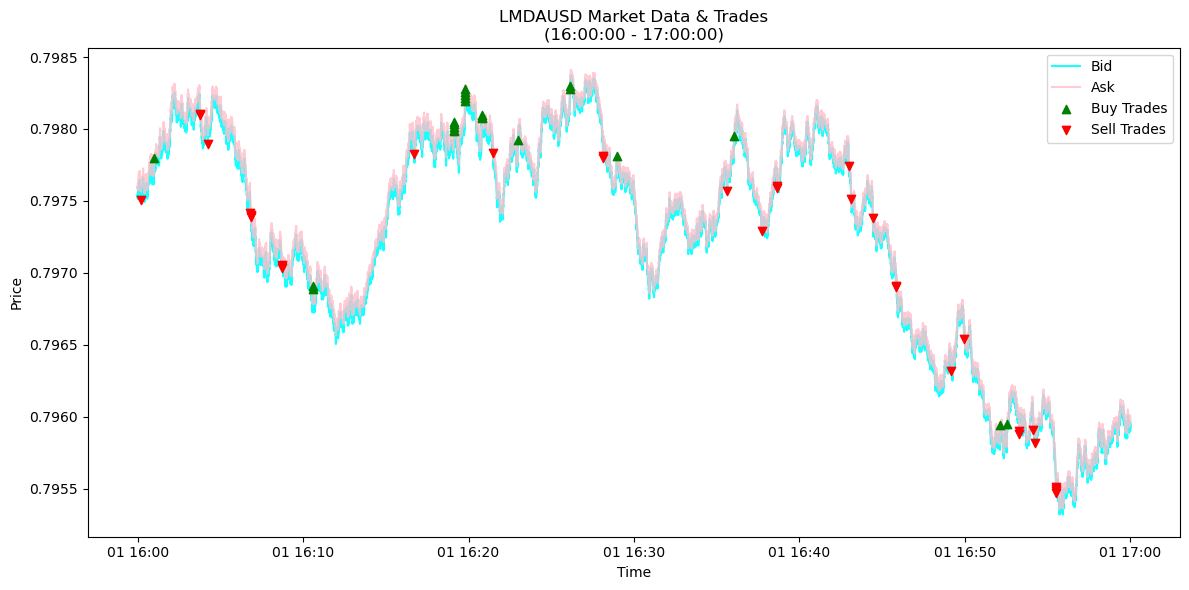

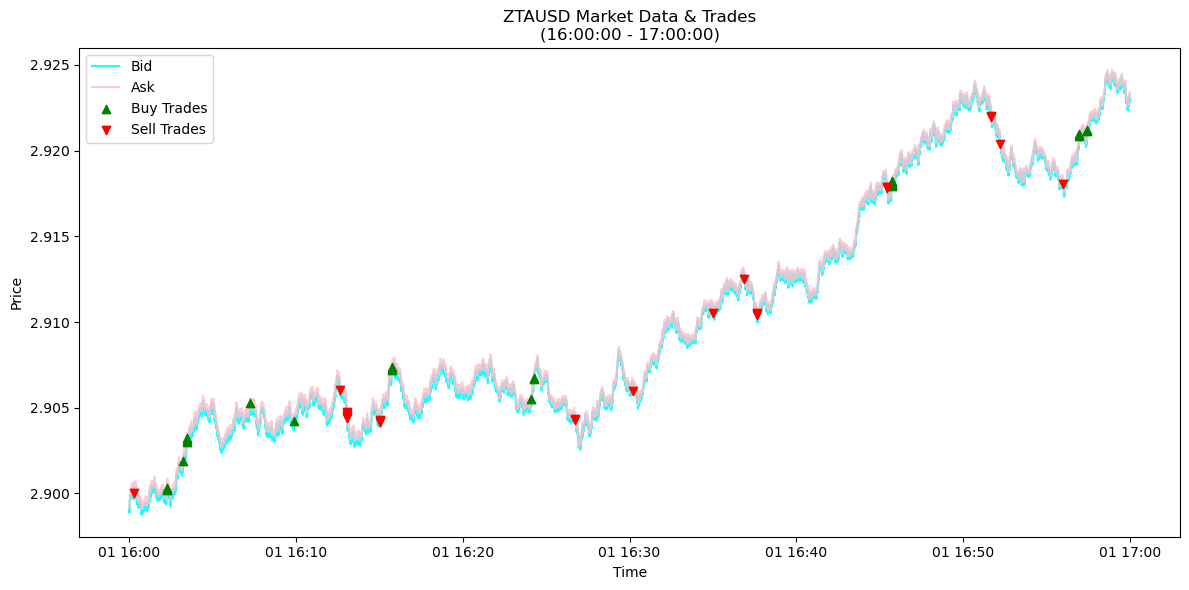

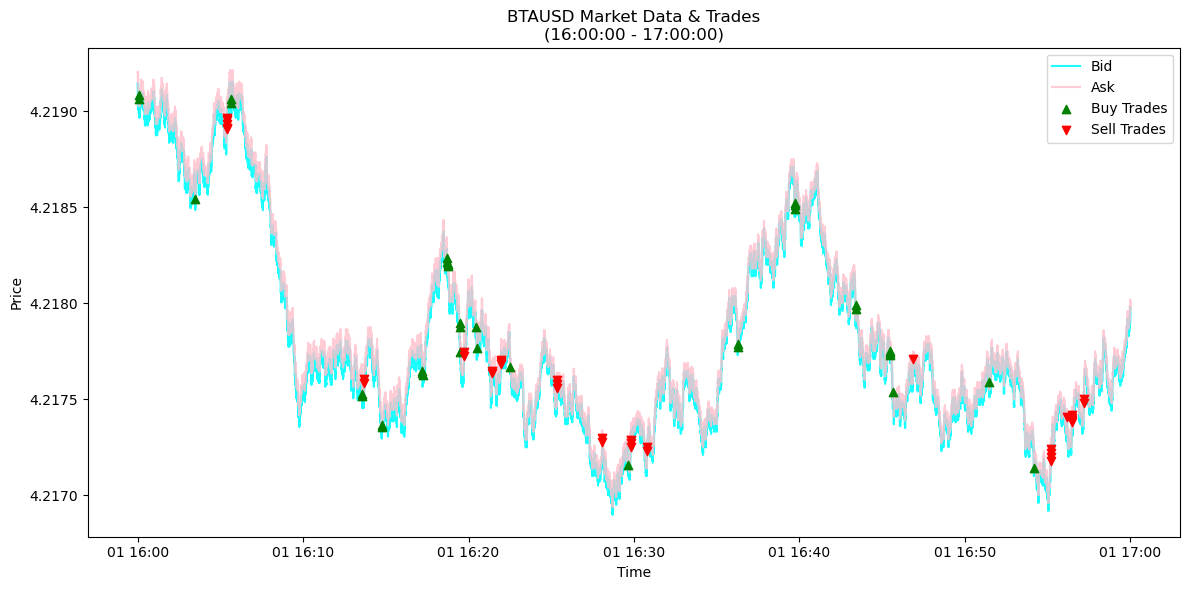

In [17]:
for instrument in L_instruments:
    # Load Data
    
    #Load market Data
    md = load_md(instrument)

    
    # Load trades data
    trades = load_trades(instrument)

    print('First Trade date for ' + instrument +' is: '+ str(trades['ts_ms_datetime'].iloc[0]))
    print('Last Trade date for ' + instrument +' is: '+ str(trades['ts_ms_datetime'].iloc[-1]))
    print('First Price date for ' + instrument +' is: '+ str(md['ts_ms_datetime'].iloc[0]))
    print('Last Price date for ' + instrument +' is: '+ str(md['ts_ms_datetime'].iloc[-1]))
    
    market_date = md['ts_ms_datetime'].min()  # midnight of the first trading day
    best_start = market_date + pd.Timedelta(hours=17) # Min is 23H00
    best_end = market_date + pd.Timedelta(hours=18)
    print(f"Selected fixed hour: {best_start} to {best_end}" + '\n')
    
    md_subset = filter_for_plot(md)
    trades_subset = filter_for_plot(trades)
  
    # Plot market data & trades during 16:00-17:00

    plt.figure(figsize=(12, 6))
    plt.plot(md_subset['ts_ms_datetime'], md_subset['bid'], label='Bid', color='cyan', alpha=0.9)
    plt.plot(md_subset['ts_ms_datetime'], md_subset['ask'], label='Ask', color='pink', alpha=0.8)
    
    # Separate trades by side
    buy_trades = trades_subset[trades_subset['side']== 'B']
    sell_trades = trades_subset[trades_subset['side'] == 'S']
    
    # Plot buy trades with green upward triangles
    plt.scatter(buy_trades['ts_ms_datetime'], buy_trades['px'], 
                marker='^', color='green', label='Buy Trades', zorder=5)
    
    # Plot sell trades with red downward triangles
    plt.scatter(sell_trades['ts_ms_datetime'], sell_trades['px'], 
                marker='v', color='red', label='Sell Trades', zorder=5)
    
    plt.xlabel("Time")
    plt.ylabel("Price")
    plt.title(f"{instrument} Market Data & Trades\n({best_start.strftime('%H:%M:%S')} - {best_end.strftime('%H:%M:%S')})")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{instrument}_market_trades_WMCO.png")
    
    

Here we could improve the selection of data by comparion the trading volume of the two days and taking the one with the highest trading volume between 4.00pm and 5.00pm

# A plot visualizing the aggregate markout curve of all trades for the symbol, using the intervals specified

### Compute & Plot aggregate markout curve

GMMAUSD
LMDAUSD
ZTAUSD
BTAUSD


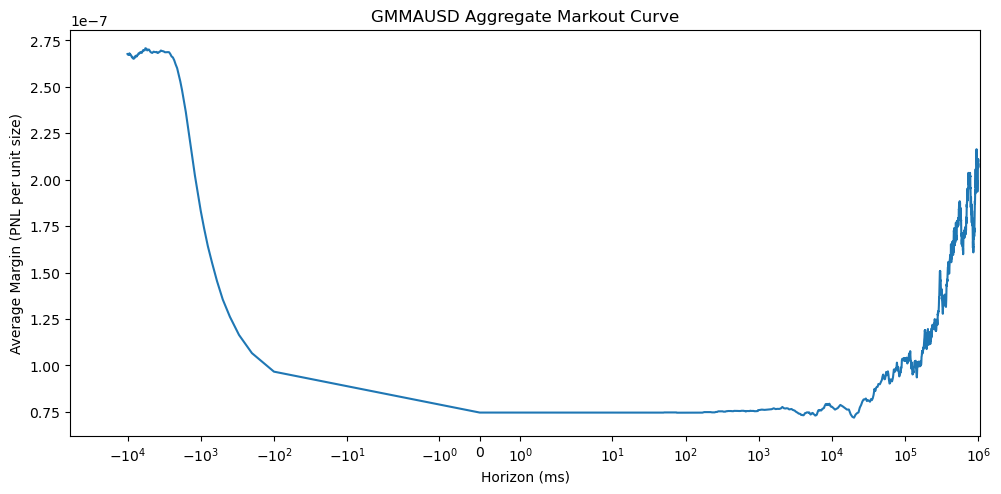

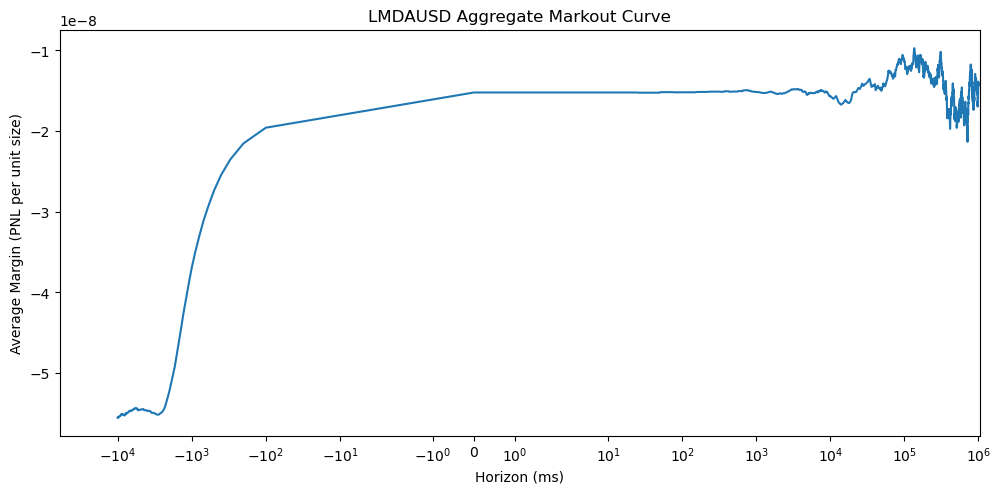

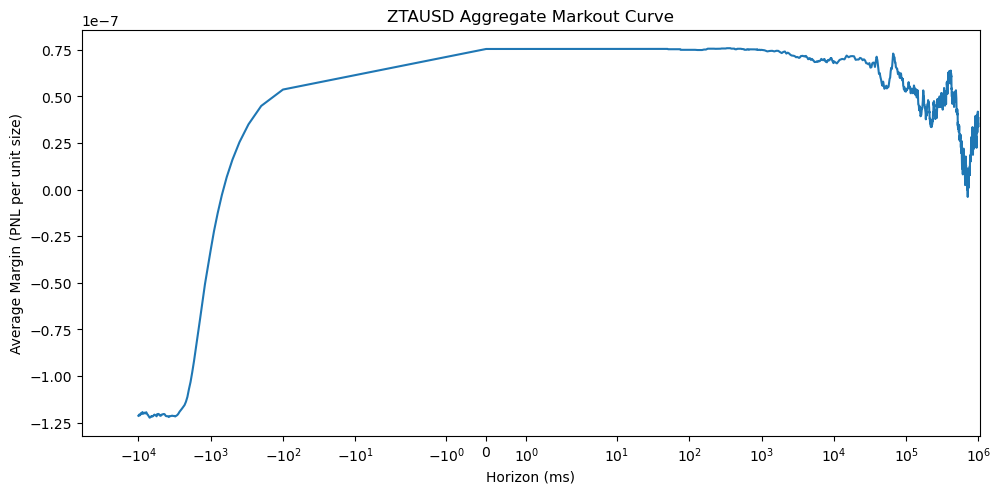

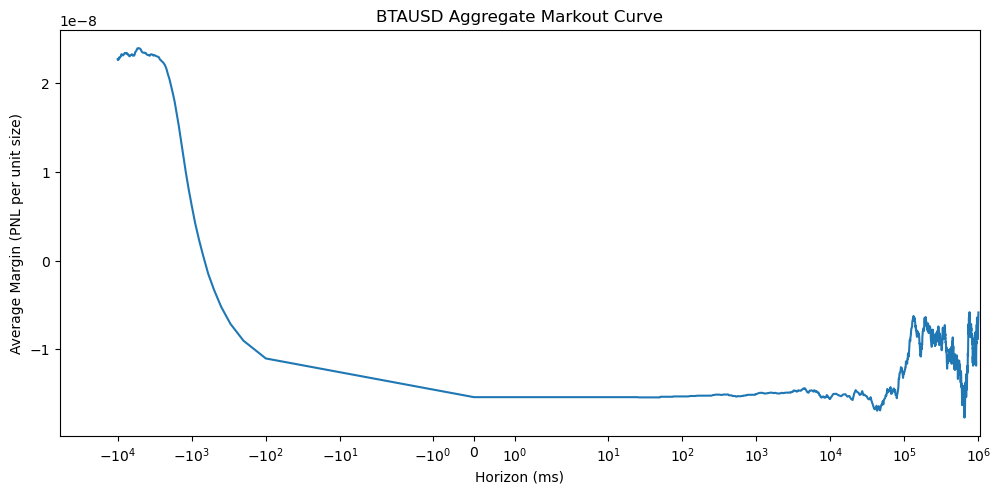

In [18]:
for instrument in L_instruments:
    print(instrument)

    
    # Load market and trades data
    md = load_md(instrument)
    trades = load_trades(instrument)
    
    # Sort market data by timestamp and reset index for easier access
    md_sorted = md.sort_values("ts_ms").reset_index(drop=True)
    md_ts = md_sorted['ts_ms'].values  # Sorted timestamps from market data
    md_mid = md_sorted['mid'].values   # Corresponding mid prices

    # Extract trade data as NumPy arrays
    trades_ts   = trades['ts_ms'].values
    trades_px   = trades['px'].values
    trades_size = trades['size'].values
    trades_side = trades['side'].values

    avg_margin = []
    for tick in horizon_ticks:
        
        # Compute target time for each trade
        target_times = trades_ts + tick

        # Find the index in md_sorted where each target_time would be inserted (i.e. first md entry with ts >= target_time)
        indices = np.searchsorted(md_ts, target_times, side='left')-1
        
        # Initialize an array to hold future mid prices, default to NaN
        future_mid = np.full(trades_ts.shape, np.nan, dtype=float)
        valid = indices < len(md_ts)  # Only consider indices within range
        future_mid[valid] = md_mid[indices[valid]]
        
        # Compute PNL: for a buy, pnl = future_mid - trade_px; for a sell, pnl = trade_px - future_mid
        pnl = np.where(trades_side == "B", future_mid - trades_px, trades_px - future_mid)
        margin = pnl / trades_size  # Margin per unit size
        
        # Calculate average margin ignoring NaNs
        avg_margin_tick = np.nanmean(margin)
        avg_margin.append(avg_margin_tick)
        
    # Plot the Aggregate Markout Curve
    plt.figure(figsize=(10, 5))
    plt.plot(horizon_ticks, avg_margin, linestyle='-')
    plt.xlabel("Horizon (ms)")
    plt.ylabel("Average Margin (PNL per unit size)")
    plt.title(f"{instrument} Aggregate Markout Curve")
    plt.tight_layout()
    plt.xscale("symlog")
    plt.savefig(f"{instrument}_markout_curve.png")

# Plot MD Over The All Period

First Trade date for GMMAUSD is: 2023-05-01 13:35:09.824999936
Last Trade date for GMMAUSD is: 2023-05-02 16:07:01.475000064
First Price date for GMMAUSD is: 2023-04-30 23:00:00
Last Price date for GMMAUSD is: 2023-05-02 22:59:59.900000
Selected fixed hour: 2023-04-30 23:00:00 to 2023-05-02 22:59:59.900000

First Trade date for LMDAUSD is: 2023-05-01 03:57:09.249999872
Last Trade date for LMDAUSD is: 2023-05-02 12:16:29.849999872
First Price date for LMDAUSD is: 2023-04-30 23:00:00
Last Price date for LMDAUSD is: 2023-05-02 22:59:59.900000
Selected fixed hour: 2023-04-30 23:00:00 to 2023-05-02 22:59:59.900000

First Trade date for ZTAUSD is: 2023-05-02 21:12:46.950000128
Last Trade date for ZTAUSD is: 2023-05-02 01:03:32.550000128
First Price date for ZTAUSD is: 2023-04-30 23:00:00
Last Price date for ZTAUSD is: 2023-05-02 22:59:59.900000
Selected fixed hour: 2023-04-30 23:00:00 to 2023-05-02 22:59:59.900000

First Trade date for BTAUSD is: 2023-05-02 20:02:20.424999936
Last Trade date

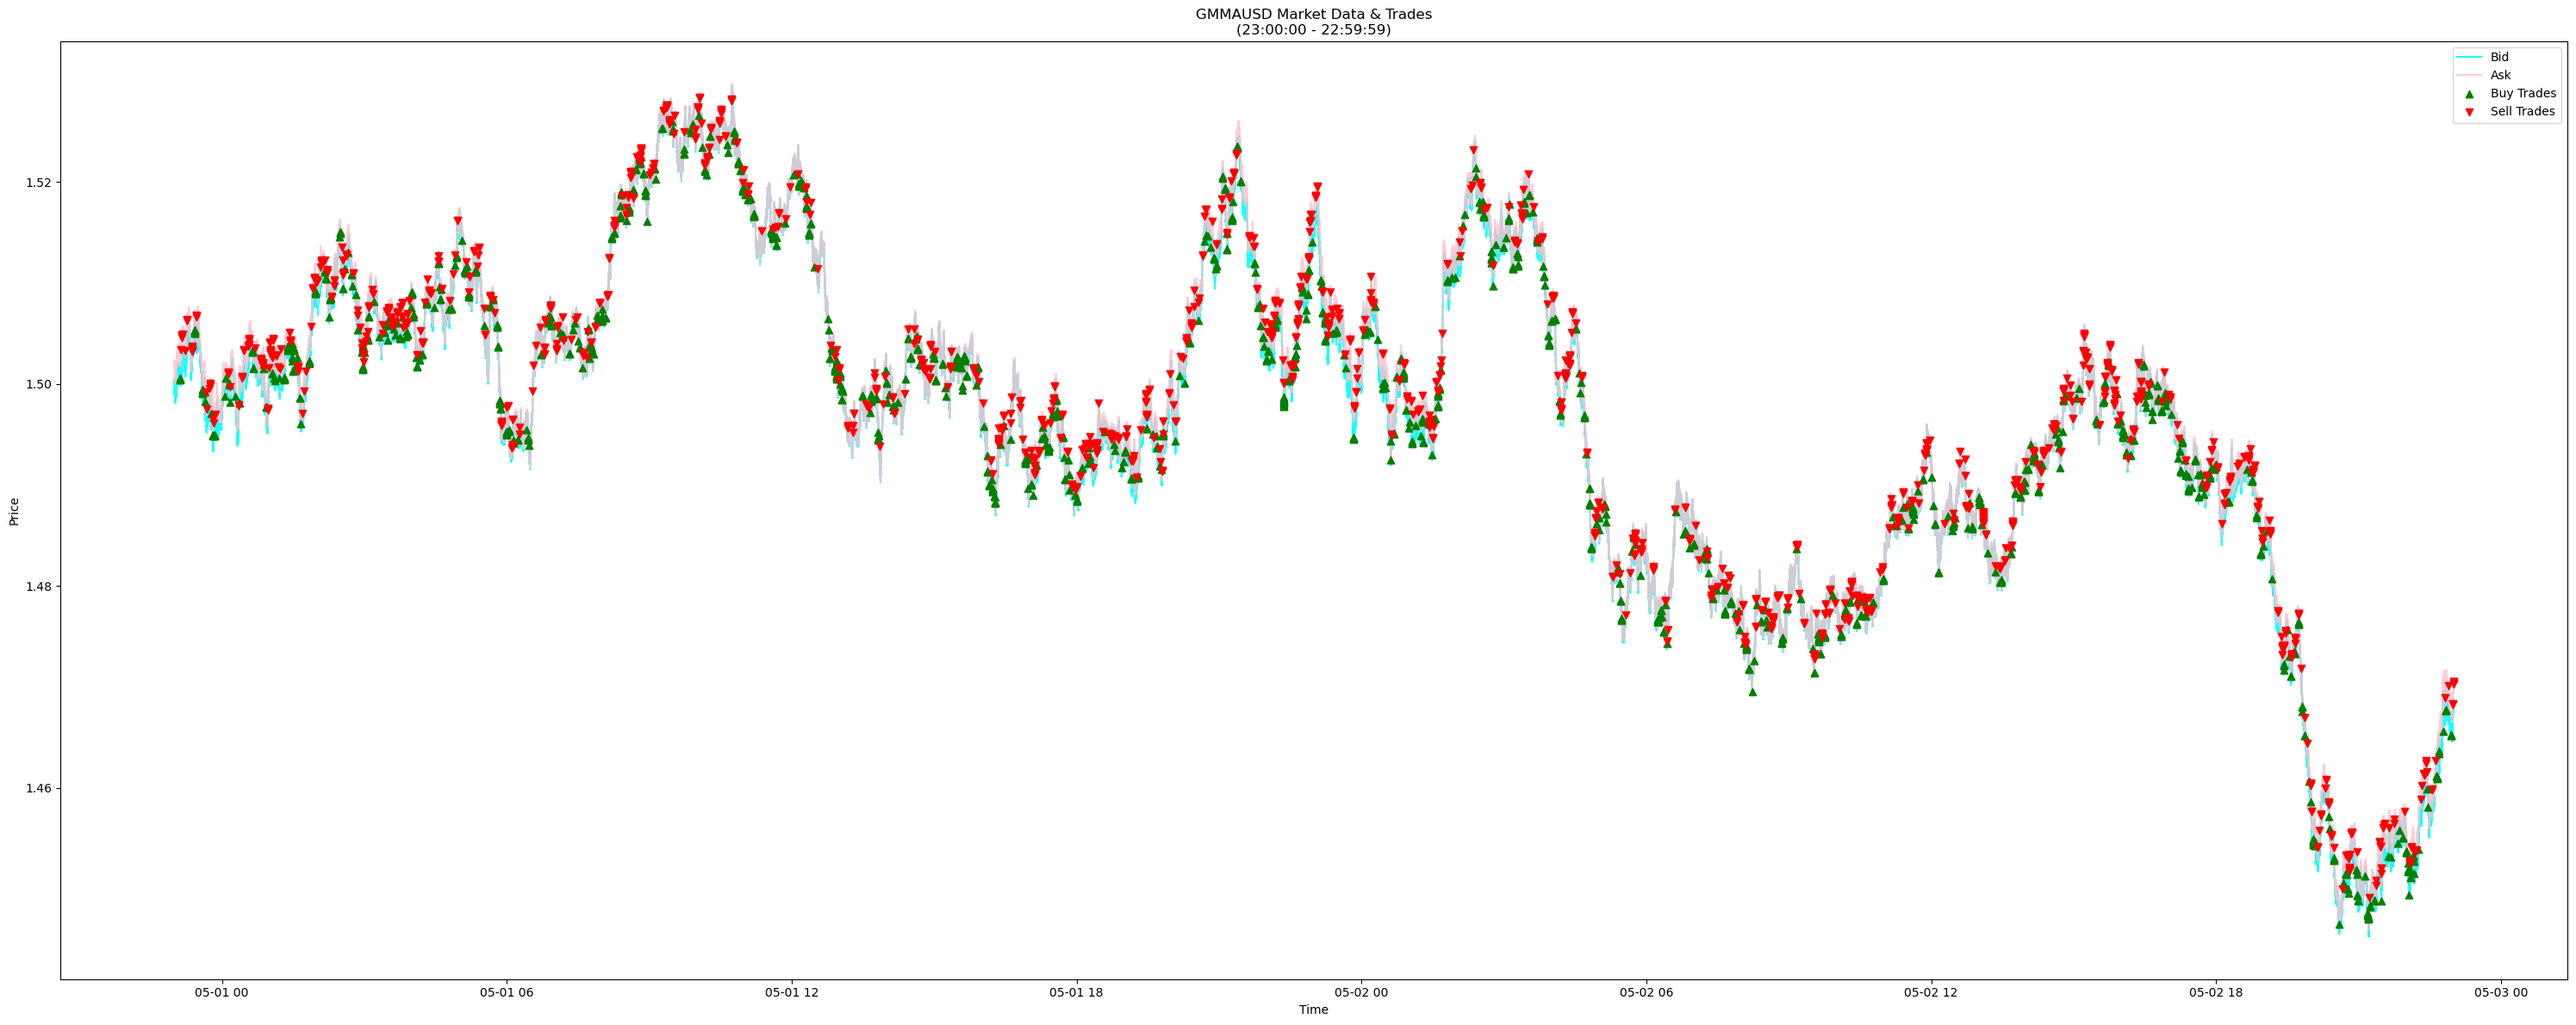

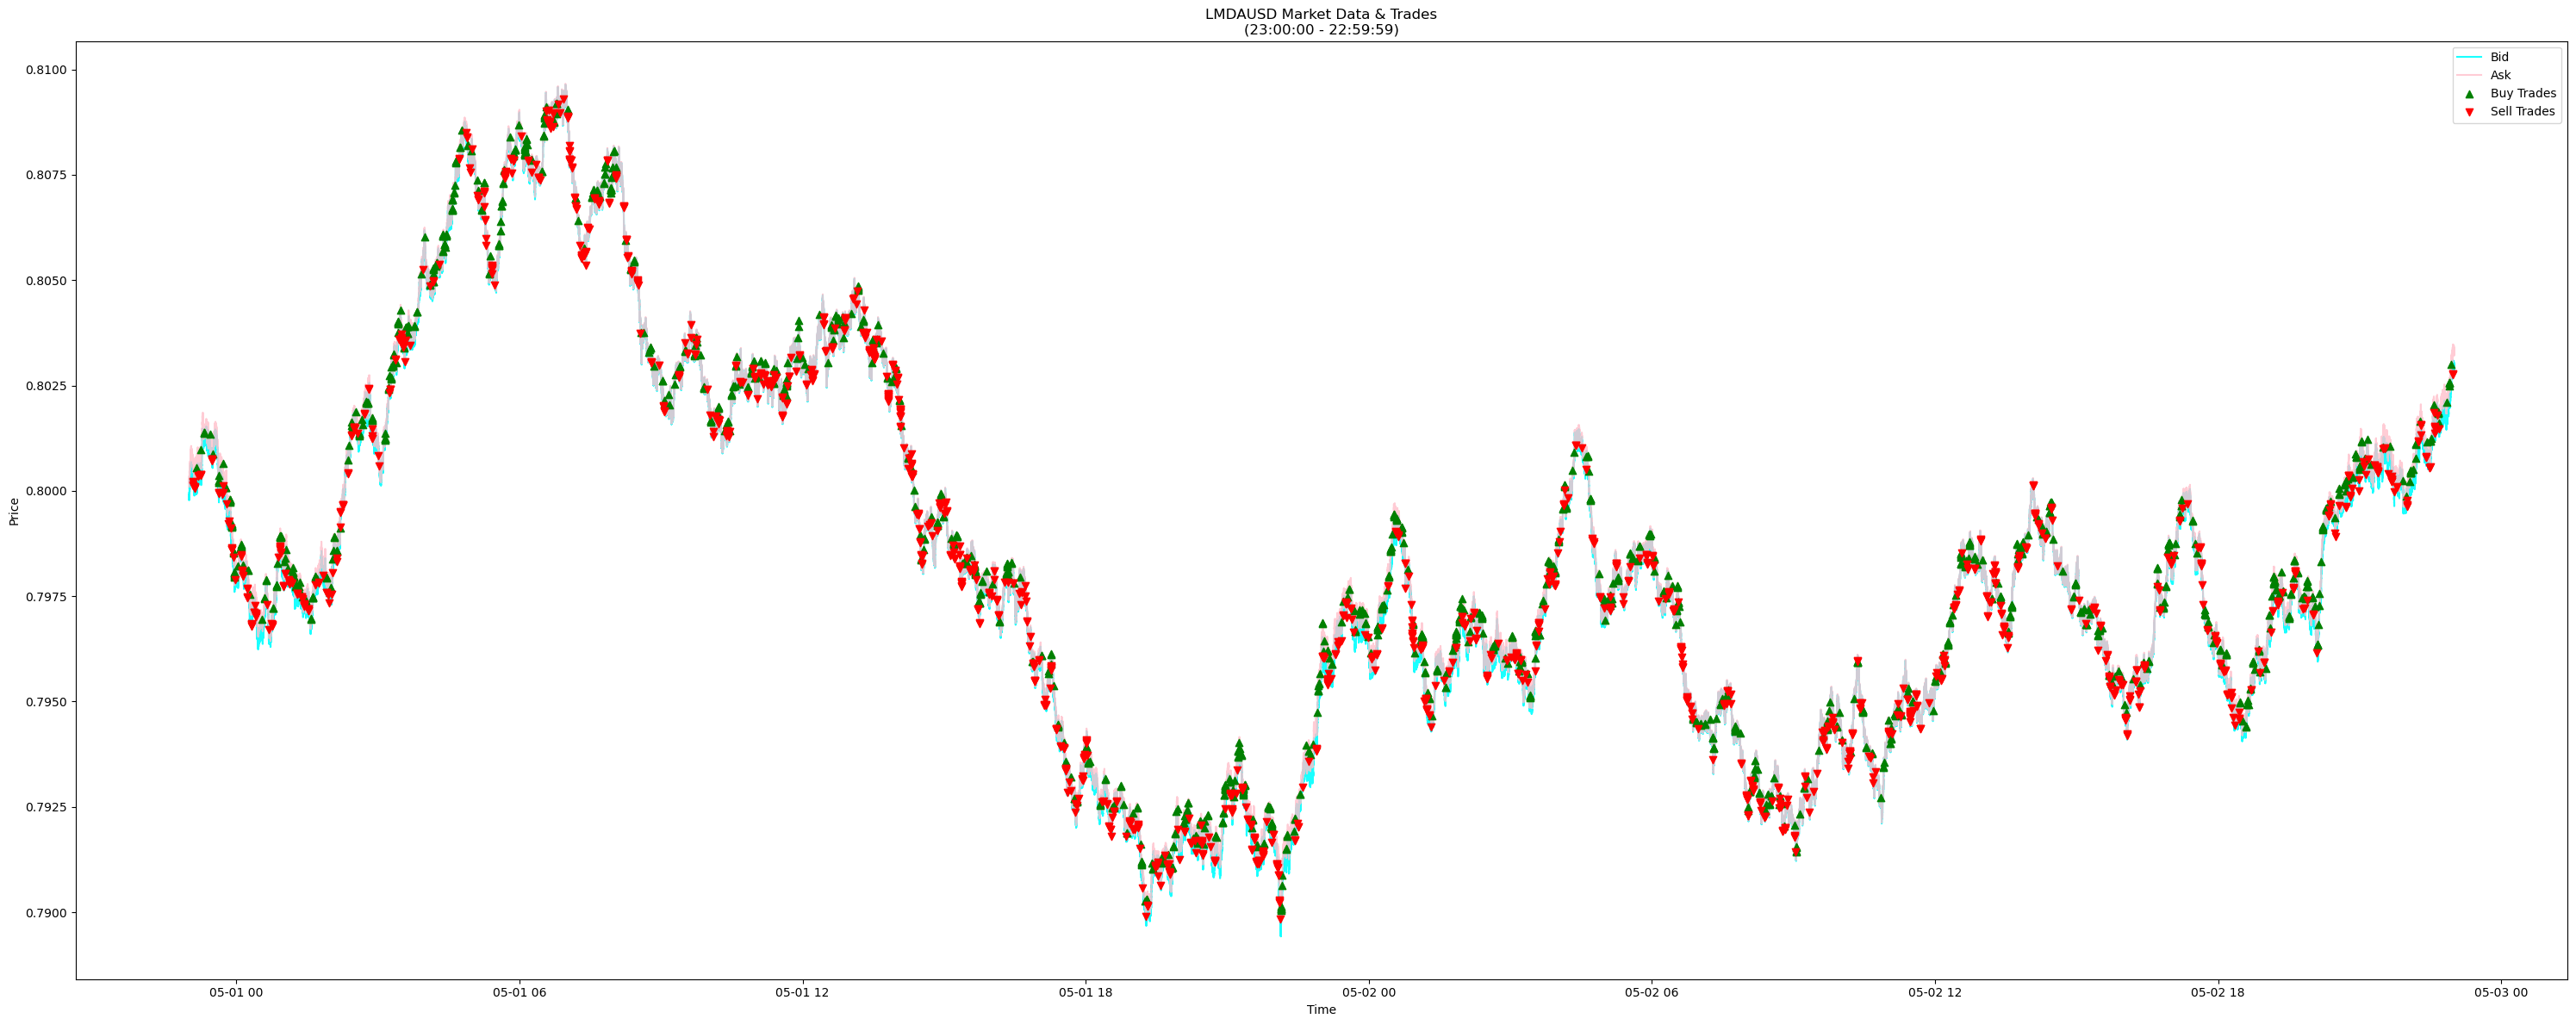

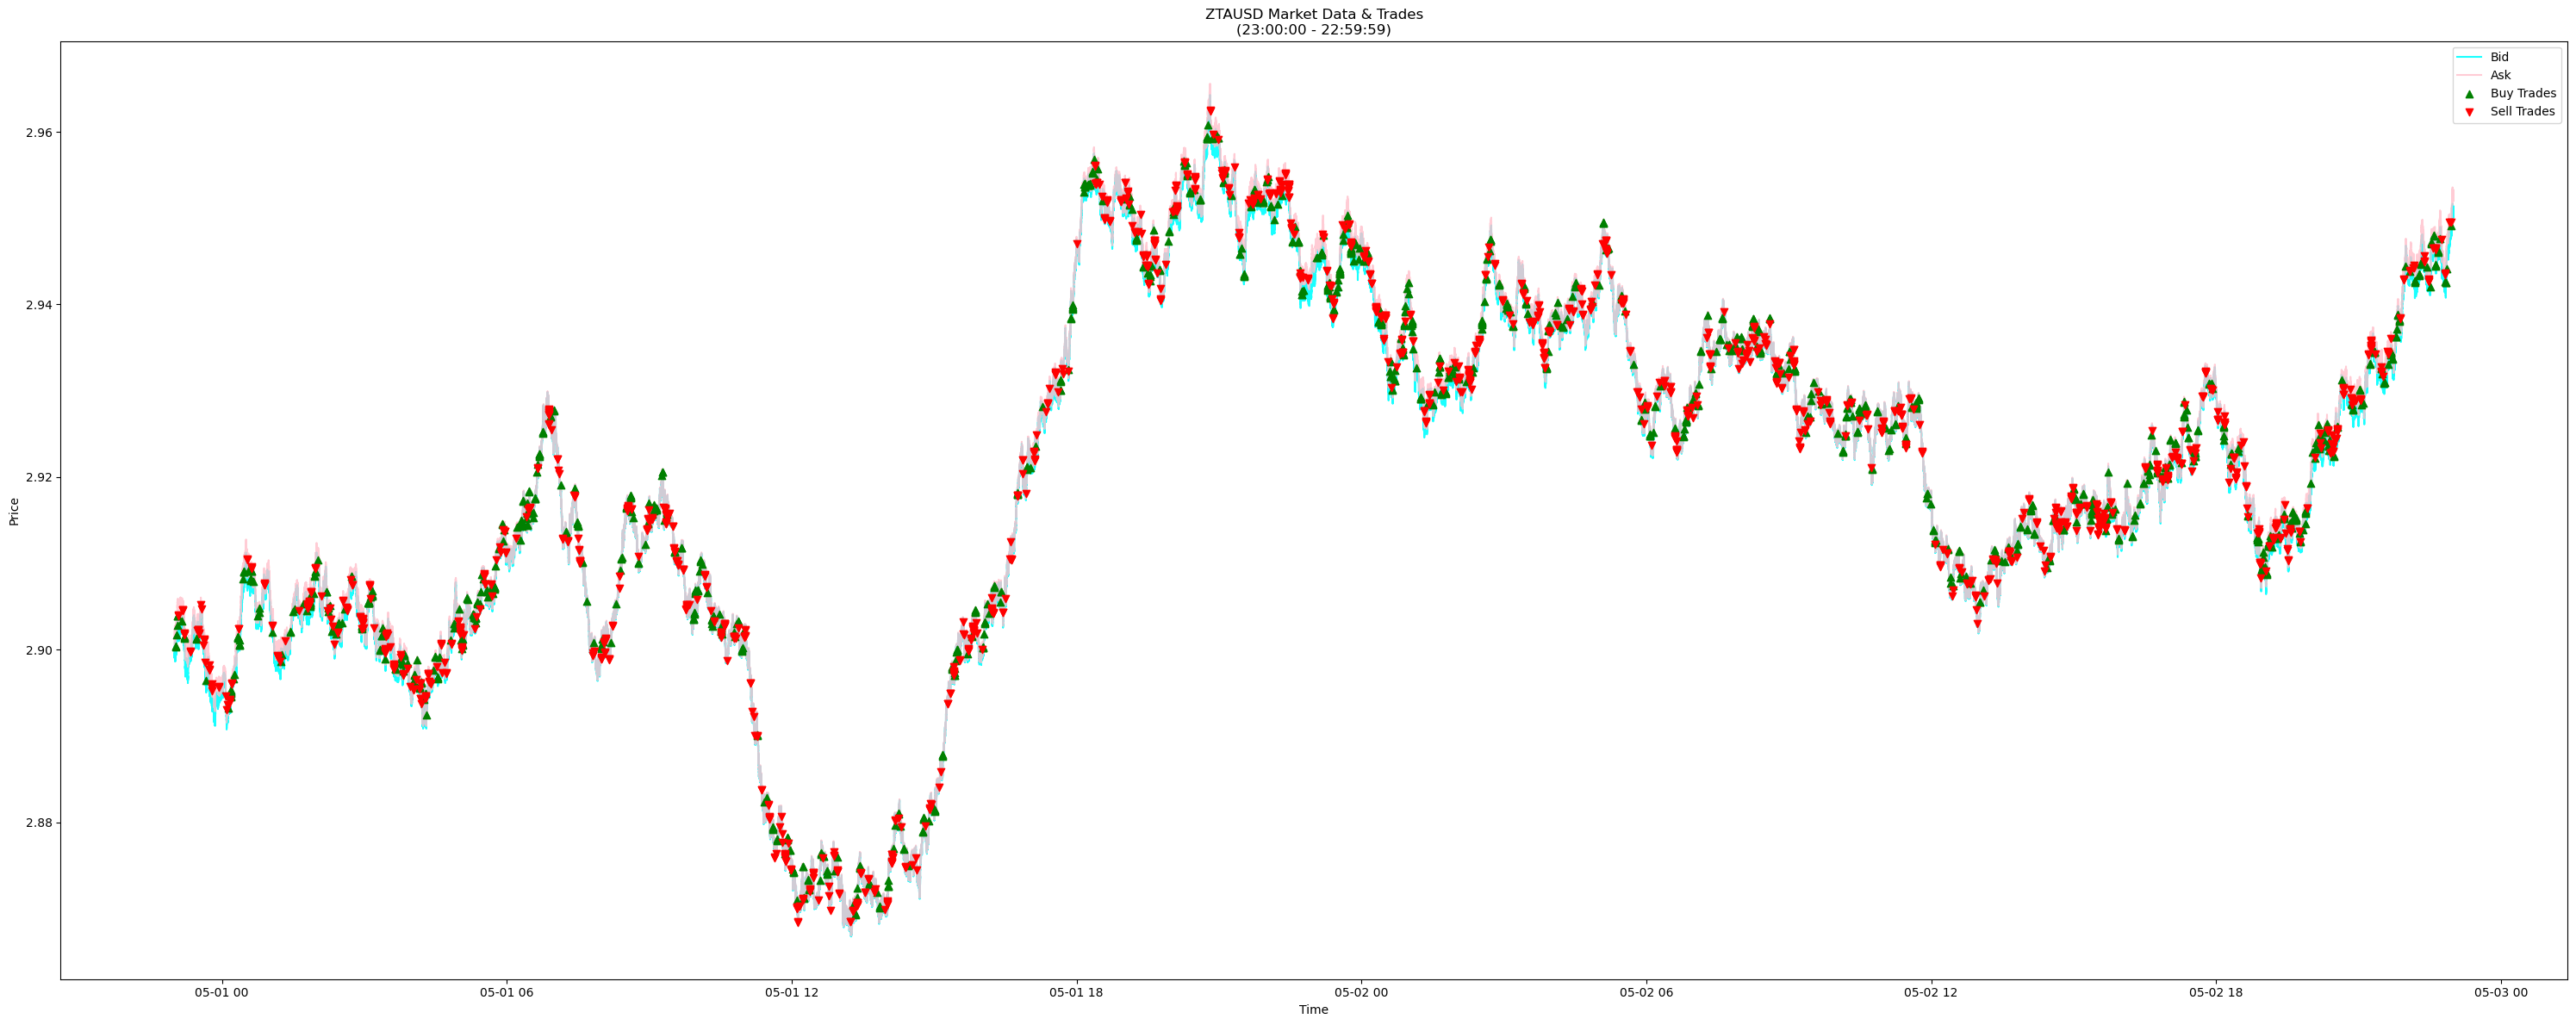

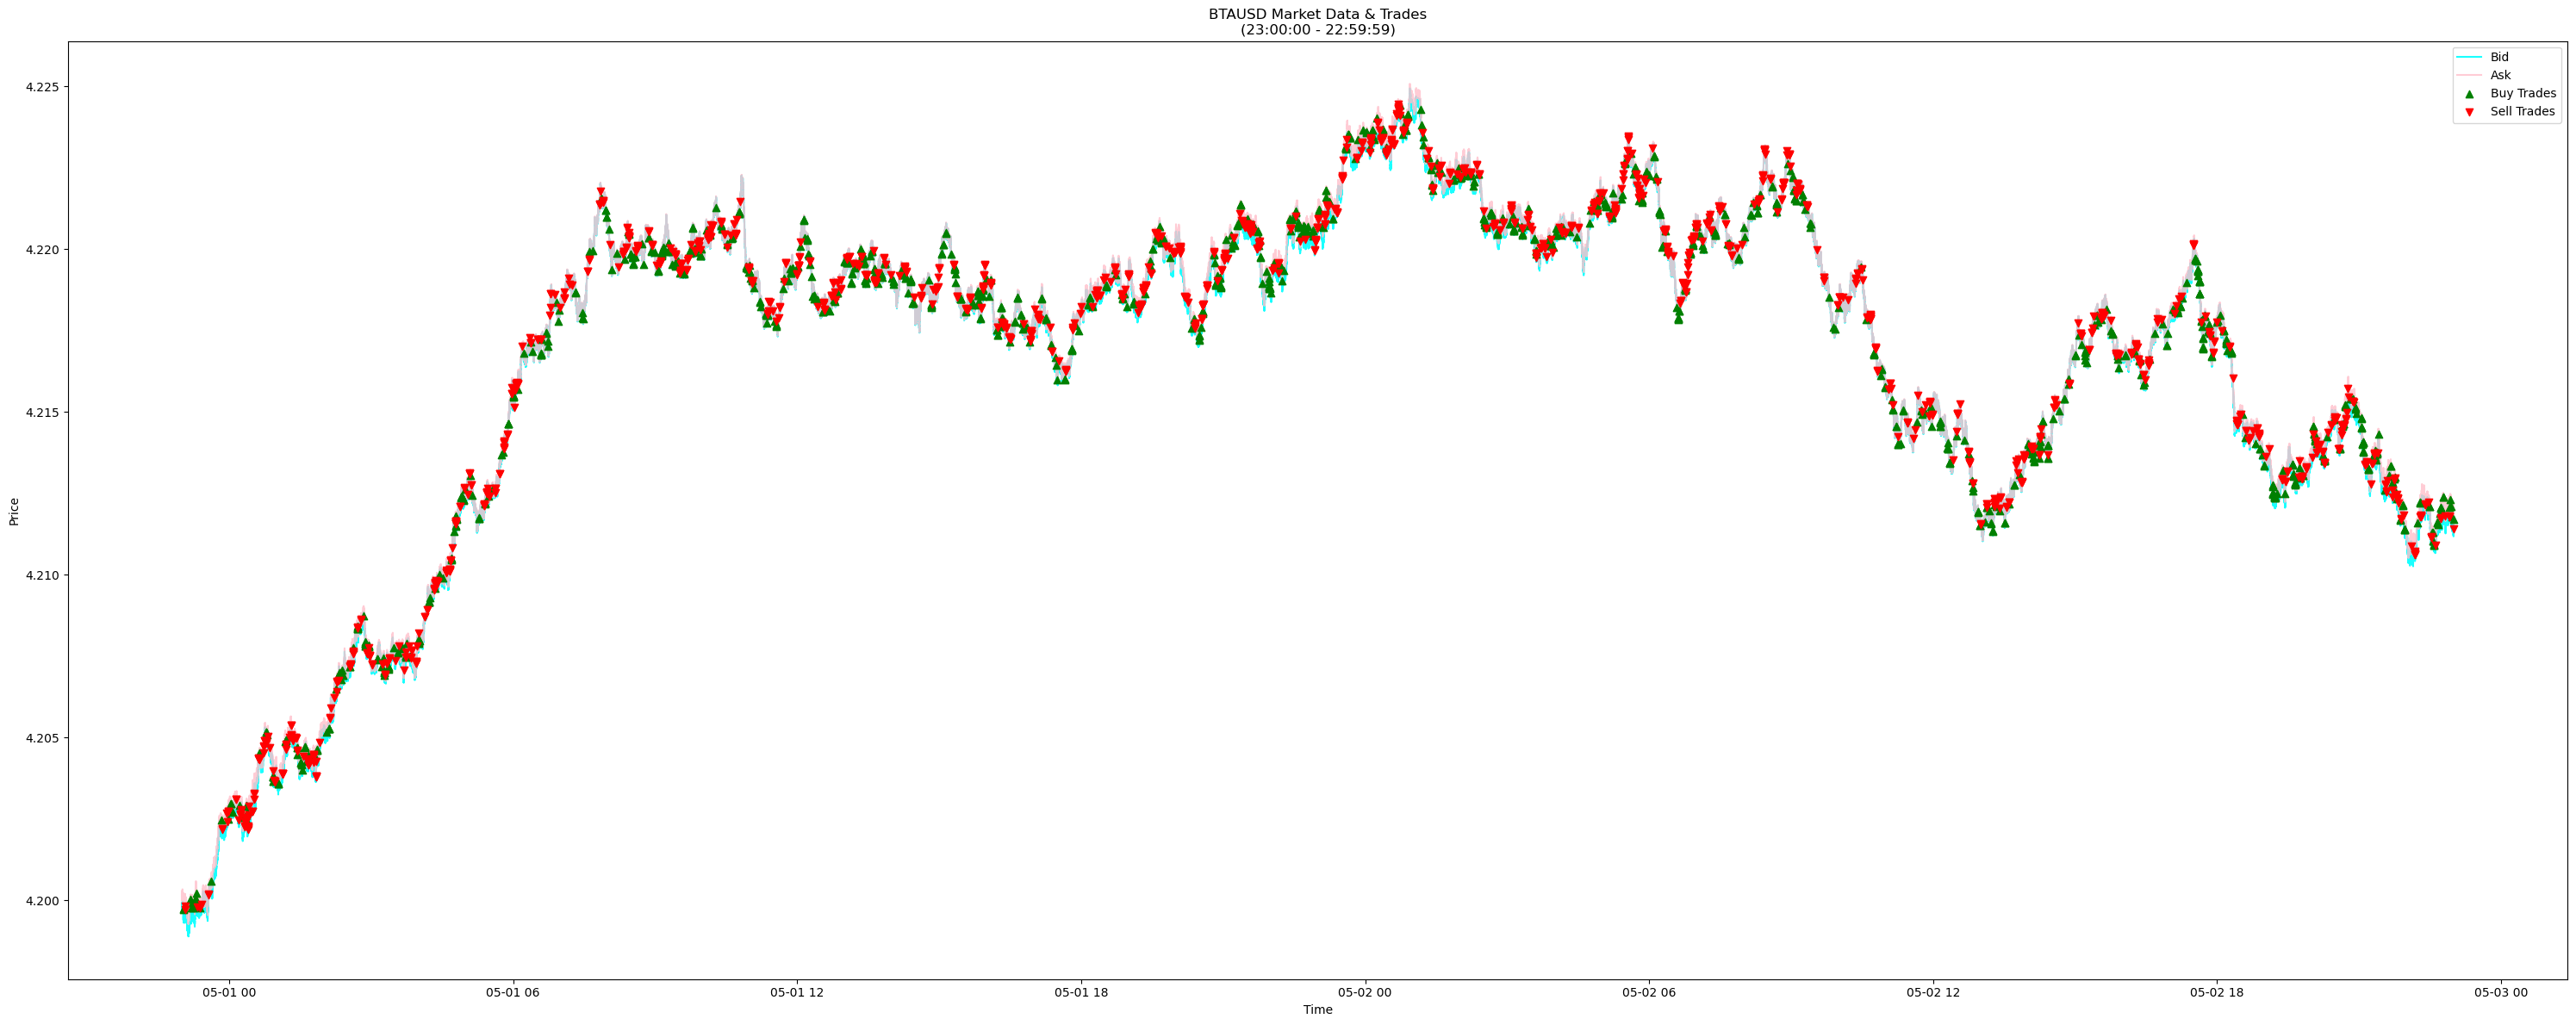

In [19]:
for instrument in L_instruments:
    # Load Data

    
    #Load market Data
    md = load_md(instrument)

    
    # Load trades data
    trades = load_trades(instrument)

    print('First Trade date for ' + instrument +' is: '+ str(trades['ts_ms_datetime'].iloc[0]))
    print('Last Trade date for ' + instrument +' is: '+ str(trades['ts_ms_datetime'].iloc[-1]))
    print('First Price date for ' + instrument +' is: '+ str(md['ts_ms_datetime'].iloc[0]))
    print('Last Price date for ' + instrument +' is: '+ str(md['ts_ms_datetime'].iloc[-1]))
    
    market_date_min = md['ts_ms_datetime'].min()  # midnight of the first trading day
    market_date_max = md['ts_ms_datetime'].max()
    best_start = market_date_min # Min is 23H00
    best_end = market_date_max
    print(f"Selected fixed hour: {best_start} to {best_end}" + '\n')
    
    md_subset = filter_for_plot(md)
    trades_subset = filter_for_plot(trades)
    
    # Plot market data & trades during 16:00-17:00

    plt.figure(figsize=(30, 12))
    plt.plot(md_subset['ts_ms_datetime'], md_subset['bid'], label='Bid', color='cyan', alpha=0.9)
    plt.plot(md_subset['ts_ms_datetime'], md_subset['ask'], label='Ask', color='pink', alpha=0.8)
    
    # Separate trades by side
    buy_trades = trades_subset[trades_subset['side']== 'B']
    sell_trades = trades_subset[trades_subset['side'] == 'S']
    
    # Plot buy trades with green upward triangles
    plt.scatter(buy_trades['ts_ms_datetime'], buy_trades['px'], 
                marker='^', color='green', label='Buy Trades', zorder=5)
    
    # Plot sell trades with red downward triangles
    plt.scatter(sell_trades['ts_ms_datetime'], sell_trades['px'], 
                marker='v', color='red', label='Sell Trades', zorder=5)
    
    plt.xlabel("Time")
    plt.ylabel("Price")
    plt.title(f"{instrument} Market Data & Trades\n({best_start.strftime('%H:%M:%S')} - {best_end.strftime('%H:%M:%S')})")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{instrument}_market_trades_WMCO_full.png")
    

# Construction Of The Order Book

In [20]:
def reconstruct_order_book(md, trades):
    """
    Reconstruct the order book by matching each trade
    to the corresponding market data snapshot using searchsorted.
    
    Parameters:
        md (pd.DataFrame): Market data snapshots, must be sorted by 'timestamp'.
                           columns: 'tm_ms', 'bid', 'ask', 'mid', 'ts_ms_datetime'.
        trades (pd.DataFrame): Trades data, must include 'tm_ms', 'px', 'size', 'side', 'ts_ms_datetime'.
    
    Returns:
        pd.DataFrame: A DataFrame with each trade and the corresponding market data snapshot.
    """
    # Ensure both DataFrames are sorted by timestamp
    md = md.sort_values('ts_ms').reset_index(drop=True)
    trades = trades.sort_values('ts_ms').reset_index(drop=True)
    
    # Create arrays of timestamps
    md_timestamps = md['ts_ms'].values
    trade_timestamps = trades['ts_ms'].values

    # For each trade, find the index in md where the market data timestamp is just greater than or equal to the trade's timestamp.
    indices = np.searchsorted(md_timestamps, trade_timestamps, side='right')-1
    
    # Some trades may occur after the last market snapshot. We filter those out.
    valid_mask = indices < len(md)
    if not valid_mask.all():
        trades = trades.loc[valid_mask].reset_index(drop=True)
        indices = indices[valid_mask]
    
    # Get the corresponding market snapshot rows
    matched_md = md.iloc[indices].reset_index(drop=True)
    
    # Combine trade information with the corresponding market snapshot.
    order_carnet = trades.copy()
    order_carnet['snapshot_timestamp'] = matched_md['ts_ms']
    order_carnet['snapshot_bid'] = matched_md['bid']
    order_carnet['snapshot_ask'] = matched_md['ask']
    if 'mid' in matched_md.columns:
        order_carnet['snapshot_mid'] = matched_md['mid']
    
    return order_carnet

In [21]:
for instrument in L_instruments:
        # Load Data
        # Load metadata
    with open(f"{instrument}.json", "r") as f:
        meta = json.load(f)

        #Load market Data
    md = load_md(instrument)


        # Load trades data
    trades = load_trades(instrument)
    order_book = reconstruct_order_book(md, trades)
    
    # Price Takers buy at the ask price and sell at the bid price
    # Market Makers buy at the bid price and sells at the ask price
    
    # Classify each trade as either maker or taker
    order_book['trade_type'] = 'Taker'  # Default assumption
    order_book.loc[(order_book['side'] == 'B') & (order_book['px'] <= order_book['snapshot_bid']), 'trade_type'] = 'Maker'
    order_book.loc[(order_book['side'] == 'S') & (order_book['px'] >= order_book['snapshot_ask']), 'trade_type'] = 'Maker'

# Count the number of maker and taker trades
    trade_counts = order_book['trade_type'].value_counts()
    print(instrument)
    print(trade_counts)
    
    
    order_book.to_csv(f"order_book {instrument}.csv")
    

GMMAUSD
Maker    2963
Name: trade_type, dtype: int64
LMDAUSD
Taker    3157
Name: trade_type, dtype: int64
ZTAUSD
Maker    2971
Name: trade_type, dtype: int64
BTAUSD
Taker    2977
Name: trade_type, dtype: int64


# Maximum Drawdown

In [22]:
for instrument in L_instruments:
    print(instrument)

    # Load and sort trade data
    trades = load_trades(instrument)
    trades_sorted = trades.sort_values("ts_ms")

# Calculate PNL over time
# For each trade, we'll calculate the profit or loss based on the trade direction (buy or sell) and price.
# We need to keep track of the current position size (for calculating unrealized profit/loss) and the trade price.

# Initialize variables for tracking
    position = 0
    pnl = []

    # Iterate through each trade to compute the mark-to-market PNL
    for index, row in trades.iterrows():
        if row['side'] == 'B':  # Buy order
            position += row['size']
        else:  # Sell order
            position -= row['size']

        # The mark-to-market PNL for this trade depends on the current position and the trade price
        # We'll use the price at each trade to compute the unrealized PNL
        current_pnl = position * row['px']
        pnl.append(current_pnl)

    # Add PNL to the dataframe
    trades['pnl'] = pnl

    # Calculate the drawdown
    max_pnl = trades['pnl'].max()
    trades['drawdown'] = trades['pnl'] - max_pnl

    # Identify the maximum drawdown and the timestamp when it occurred
    max_drawdown = trades['drawdown'].min()
    max_drawdown_timestamp = trades.iloc[trades['drawdown'].idxmin()]['ts_ms_datetime']
    print(f"Max Drawdown for {instrument} is {max_drawdown} and it happens on {max_drawdown_timestamp}" + '\n')
    print(f"PnL for {instrument} is {sum(pnl)}"  + '\n')


GMMAUSD
Max Drawdown for GMMAUSD is -669628.6499999999 and it happens on 2023-05-01 18:25:48.375000064

PnL for GMMAUSD is -179855938.4499996

LMDAUSD
Max Drawdown for LMDAUSD is -843793.82 and it happens on 2023-05-02 12:57:48.324999936

PnL for LMDAUSD is 929066021.0249995

ZTAUSD
Max Drawdown for ZTAUSD is -2389841.4 and it happens on 2023-05-01 19:37:56.124999936

PnL for ZTAUSD is -2611130675.074999

BTAUSD
Max Drawdown for BTAUSD is -1746875.7300000002 and it happens on 2023-05-01 22:10:18.449999872

PnL for BTAUSD is -3143877384.855002

